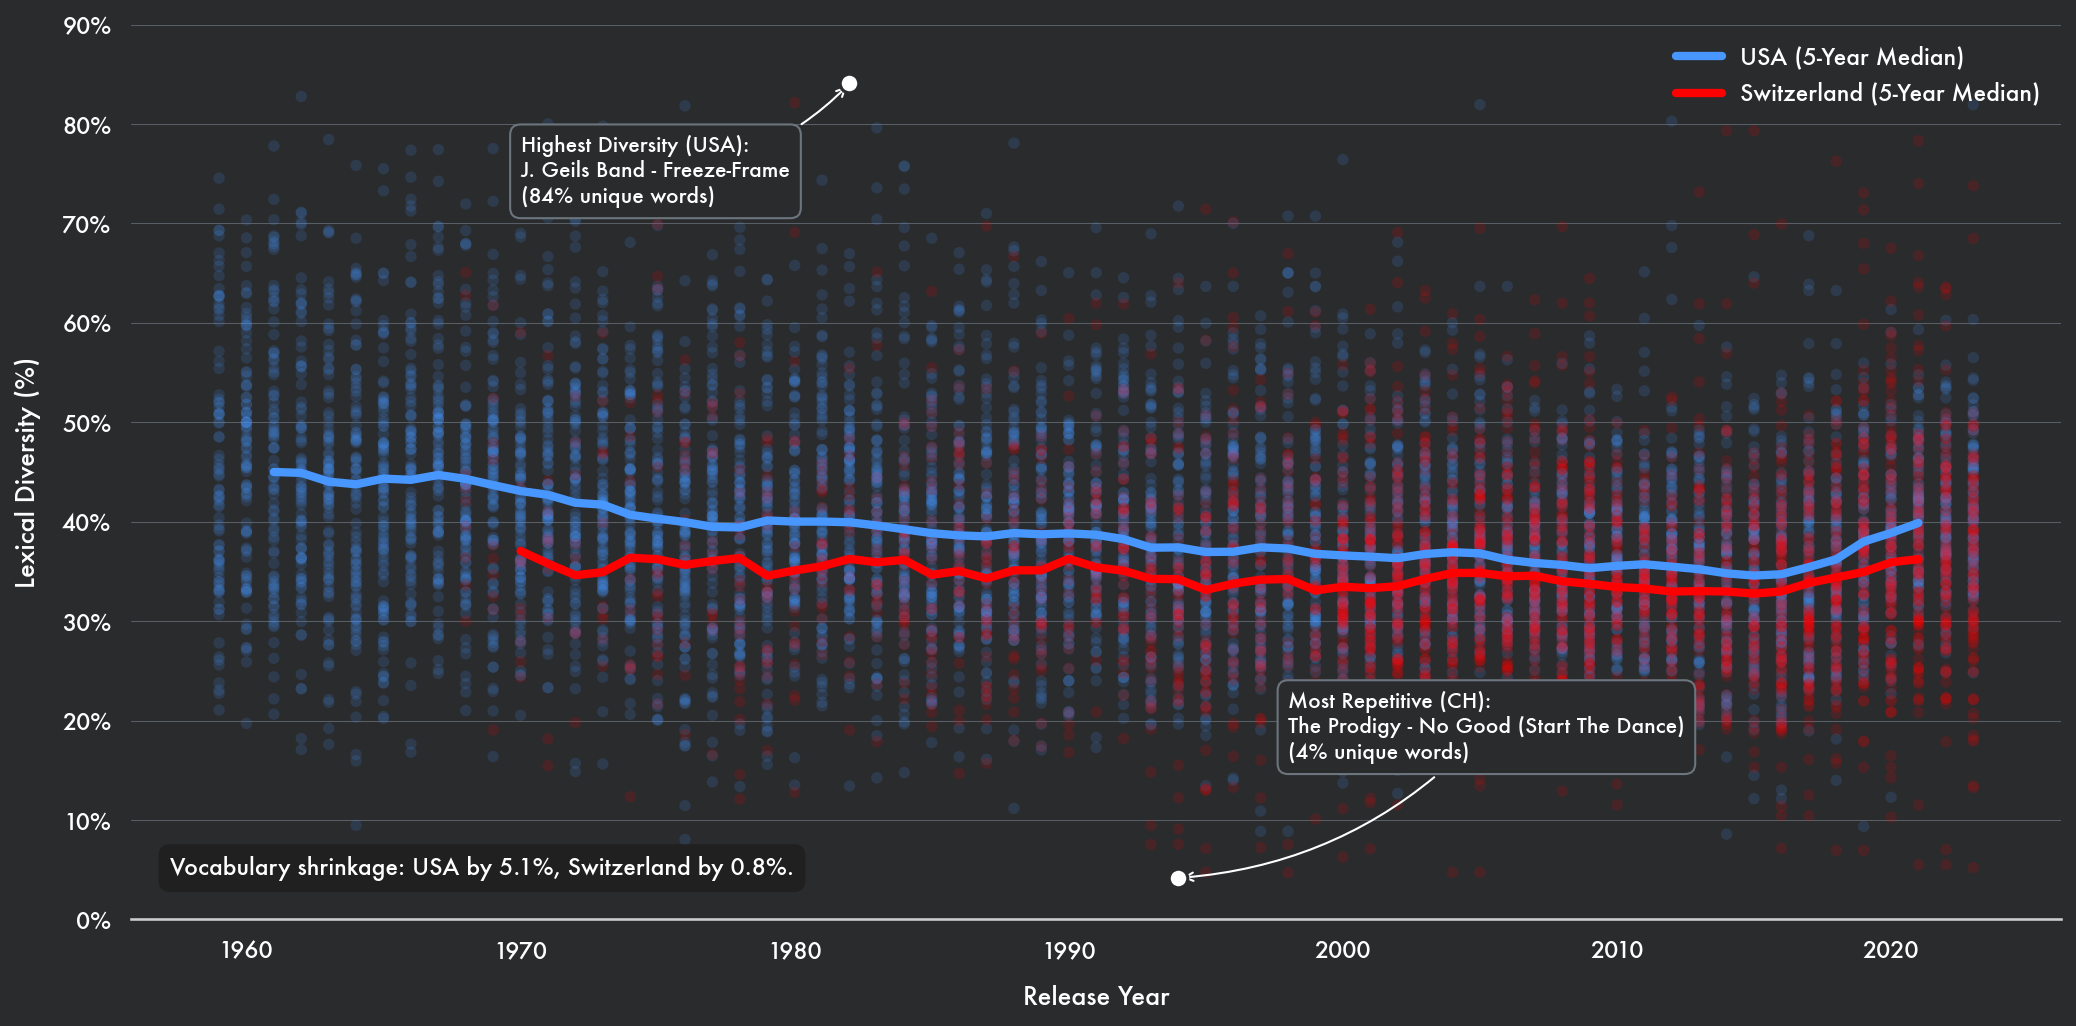

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm
import json

with open('config.json', 'r') as f:
    config = json.load(f)

# Assign colors from config
BG_COLOR = config["colors"]["BG_COLOR"]
TITLE_COLOR = config["colors"]["TITLE_COLOR"]
TEXT_COLOR = config["colors"]["TEXT_COLOR"]
US_COLOR = config["colors"]["US_COLOR"]
CH_COLOR = config["colors"]["CH_COLOR"]
GRID_COLOR = config["colors"]["GRID_COLOR"]
ACCENT_COLOR = config["colors"]["ACCENT_COLOR"]

# Load fonts from config
font_path_title = "style/" + config["fonts"]["title_font_path"]
font_path_main = "style/" + config["fonts"]["main_font_path"]

fm.fontManager.addfont(font_path_title)
fm.fontManager.addfont(font_path_main)

title_font_name = fm.FontProperties(fname=font_path_title).get_name()
main_font_name = fm.FontProperties(fname=font_path_main).get_name()


def calculate_word_metrics(text):
    """Helper function to calculate total words and unique words from a string."""
    if pd.isna(text) or not isinstance(text, str):
        return 0, 0
    words = str(text).lower().split()
    return len(words), len(set(words))


def prepare_lexical_data(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    """Tags datasets by country, calculates missing CH word counts and generates separate trendlines."""

    df_usa = df_usa.copy()
    df_ch = df_ch.copy()

    # Tag by country for splitting later
    df_usa['Country'] = 'USA'
    df_ch['Country'] = 'CH'

    # Calculate missing word counts for the swiss dataset
    if 'Lyrics' in df_ch.columns and 'Word Counts' not in df_ch.columns:
        metrics = df_ch['Lyrics'].apply(calculate_word_metrics)
        df_ch['Word Counts'] = metrics.apply(lambda x: x[0])
        df_ch['Unique Word Counts'] = metrics.apply(lambda x: x[1])
        
    # Combine USA and Switzerland data
    df = pd.concat([df_usa, df_ch], ignore_index=True)
    
    # Filter out too short songs
    df_clean = df[df['Word Counts'] > 50].copy()
    df_clean['Lexical_Diversity'] = df_clean['Unique Word Counts'] / df_clean['Word Counts']
    
    # Calculate separate yearly medians and smooth them
    yearly_trend_usa = df_clean[df_clean['Country'] == 'USA'].groupby('Year')['Lexical_Diversity'].median().reset_index()
    yearly_trend_usa['Smoothed_Trend'] = yearly_trend_usa['Lexical_Diversity'].rolling(window=5, center=True).mean()

    yearly_trend_ch = df_clean[df_clean['Country'] == 'CH'].groupby('Year')['Lexical_Diversity'].median().reset_index()
    yearly_trend_ch['Smoothed_Trend'] = yearly_trend_ch['Lexical_Diversity'].rolling(window=5, center=True).mean()

    # Find overall extremes for annotations
    most_diverse = df_clean.loc[df_clean['Lexical_Diversity'].idxmax()]
    least_diverse = df_clean.loc[df_clean['Lexical_Diversity'].idxmin()]
    
    return df_clean, yearly_trend_usa, yearly_trend_ch, most_diverse, least_diverse


def format_lexical_aesthetics(ax: plt.Axes, yearly_trend_usa: pd.DataFrame, yearly_trend_ch: pd.DataFrame, most_diverse: pd.Series, least_diverse: pd.Series):
    """Applies custom styling, labels and dynamic storytelling elements."""

    sns.despine(left=True, top=True, right=True)
    
    ax.grid(color=GRID_COLOR, linestyle='-', linewidth=0.5, axis='y', alpha=0.7)
    ax.grid(False, axis='x')

    # Format y-axis as percentage
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(y*100)}%" for y in yticks], color=TEXT_COLOR)
            
    ax.set_ylabel('Lexical Diversity (%)', fontsize=12, color=TEXT_COLOR, labelpad=10)
    ax.set_xlabel('Release Year', fontsize=12, color=TEXT_COLOR, labelpad=10)

    ax.tick_params(axis='x', colors=TEXT_COLOR)
    ax.tick_params(axis='y', colors=TEXT_COLOR)

    # Styling for text boxes
    box_style = dict(boxstyle="round,pad=0.5", fc=BG_COLOR, ec=GRID_COLOR, lw=1)

    # Annotate most diverse
    ax.annotate(f"Highest Diversity ({most_diverse['Country']}):\n{most_diverse['Artist']} - {most_diverse['Song Title']}\n({int(most_diverse['Lexical_Diversity']*100)}% unique words)", 
                xy=(most_diverse['Year'], most_diverse['Lexical_Diversity']),
                xytext=(most_diverse['Year'] - 12, most_diverse['Lexical_Diversity'] - 0.12), 
                fontsize=10, color=TEXT_COLOR, fontweight='bold',
                bbox=box_style,
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color=TEXT_COLOR))

    # Annotate least diverse
    ax.annotate(f"Most Repetitive ({least_diverse['Country']}):\n{least_diverse['Artist']} - {least_diverse['Title']}\n({int(least_diverse['Lexical_Diversity']*100)}% unique words)", 
                xy=(least_diverse['Year'], least_diverse['Lexical_Diversity']),
                xytext=(least_diverse['Year'] + 4, least_diverse['Lexical_Diversity'] + 0.12), 
                fontsize=10, color=TEXT_COLOR, fontweight='bold',
                bbox=box_style,
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=-.2", color=TEXT_COLOR))

    # Calculate shrinkage for both lines dynamically
    diff_usa = (yearly_trend_usa['Smoothed_Trend'].dropna().iloc[0] - yearly_trend_usa['Smoothed_Trend'].dropna().iloc[-1]) * 100
    diff_ch = (yearly_trend_ch['Smoothed_Trend'].dropna().iloc[0] - yearly_trend_ch['Smoothed_Trend'].dropna().iloc[-1]) * 100
    
    ax.text(0.02, 0.05, f"Vocabulary shrinkage: USA by {diff_usa:.1f}%, Switzerland by {diff_ch:.1f}%.", 
            transform=ax.transAxes, fontsize=11, color=TEXT_COLOR, fontweight='bold', style='italic',
            bbox=dict(boxstyle="round,pad=0.5", fc="#1E1E1E", ec="none", alpha=0.8))

    legend = ax.legend(frameon=False, loc='upper right', fontsize=11)
    plt.setp(legend.get_texts(), color=TEXT_COLOR)


def create_lexical_diversity_chart(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    # Get prepped data
    df_clean, yearly_trend_usa, yearly_trend_ch, most_diverse, least_diverse = prepare_lexical_data(df_usa, df_ch)

    # Canvas setup
    sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": BG_COLOR, 
        "figure.facecolor": BG_COLOR,
        "font.family": main_font_name  
    })
    
    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

    # Plotting the Data
    df_usa_clean = df_clean[df_clean['Country'] == 'USA']
    df_ch_clean = df_clean[df_clean['Country'] == 'CH']

    # Background Scatterplots
    ax.scatter(df_usa_clean['Year'], df_usa_clean['Lexical_Diversity'], 
               color=US_COLOR, alpha=0.15, s=30, edgecolors='none', zorder=1)
               
    ax.scatter(df_ch_clean['Year'], df_ch_clean['Lexical_Diversity'], 
               color=CH_COLOR, alpha=0.15, s=30, edgecolors='none', zorder=1)

    # Median Trend Lines
    ax.plot(yearly_trend_usa['Year'], yearly_trend_usa['Smoothed_Trend'], 
            color=US_COLOR, linewidth=4, label='USA (5-Year Median)', zorder=3)
            
    ax.plot(yearly_trend_ch['Year'], yearly_trend_ch['Smoothed_Trend'], 
            color=CH_COLOR, linewidth=4, label='Switzerland (5-Year Median)', zorder=3)

    # Highlight outliers
    ax.scatter([most_diverse['Year'], least_diverse['Year']], 
               [most_diverse['Lexical_Diversity'], least_diverse['Lexical_Diversity']], 
               color=TITLE_COLOR, s=80, zorder=4, edgecolor=BG_COLOR, linewidth=1.5)

    # Apply styling, labels and annotations
    format_lexical_aesthetics(ax, yearly_trend_usa, yearly_trend_ch, most_diverse, least_diverse)

    plt.tight_layout()
    return fig


if __name__ == "__main__":
    # Load datasets
    df_usa = pd.read_csv('data/US/songs_analyzed.csv')
    df_ch = pd.read_csv('data/CH/songs_analyzed.csv') 

    # Generate and show plot
    lexical_fig = create_lexical_diversity_chart(df_usa, df_ch)
    plt.show()

    # Save the chart
    lexical_fig.savefig('chartsPNG/chart3.png', dpi=300, bbox_inches='tight')